<a href="https://www.kaggle.com/code/aymanebadia/animalclassification?scriptVersionId=306250354" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **1. Imports**

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.amp import autocast
import matplotlib.pyplot as plt

# **2. Chargement du dataset CIFAR-10**

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True,
    num_workers=2,        
    pin_memory=True,    
    persistent_workers=True
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

classes = trainset.classes
print(classes)

100%|██████████| 170M/170M [00:02<00:00, 63.5MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# **3. Visualisation des données**

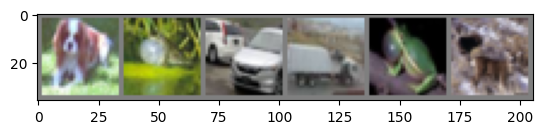

['dog', 'frog', 'automobile', 'truck', 'frog', 'deer']


In [3]:

def imshow(img):
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:6]))
print([classes[i] for i in labels[:6]])


# **4. Architecture du modèle CNN**

In [4]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

model = CNN(num_classes=10).to(device)


Device : cuda


# **5. Entrainement**

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 20
train_losses = []
PATIENCE = 5
best_loss = float('inf')
patience_ctr = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}  Loss: {epoch_loss:.4f}")
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        patience_ctr = 0
        torch.save(model.state_dict(), '/kaggle/working/model.pth')
        print("  ✔ model saved")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  ⏹ Early stopping at epoch {epoch+1}")
            break

print("✅ Training done! model.pth saved at /kaggle/working/model.pth")

Epoch 1/20  Loss: 1.2731
  ✔ model saved
Epoch 2/20  Loss: 0.9223
  ✔ model saved
Epoch 3/20  Loss: 0.8010
  ✔ model saved
Epoch 4/20  Loss: 0.7197
  ✔ model saved
Epoch 5/20  Loss: 0.6650
  ✔ model saved
Epoch 6/20  Loss: 0.5551
  ✔ model saved
Epoch 7/20  Loss: 0.5268
  ✔ model saved
Epoch 8/20  Loss: 0.4932
  ✔ model saved
Epoch 9/20  Loss: 0.4654
  ✔ model saved
Epoch 10/20  Loss: 0.4471
  ✔ model saved
Epoch 11/20  Loss: 0.3901
  ✔ model saved
Epoch 12/20  Loss: 0.3709
  ✔ model saved
Epoch 13/20  Loss: 0.3601
  ✔ model saved
Epoch 14/20  Loss: 0.3450
  ✔ model saved
Epoch 15/20  Loss: 0.3329
  ✔ model saved
Epoch 16/20  Loss: 0.3067
  ✔ model saved
Epoch 17/20  Loss: 0.2977
  ✔ model saved
Epoch 18/20  Loss: 0.2890
  ✔ model saved
Epoch 19/20  Loss: 0.2845
  ✔ model saved
Epoch 20/20  Loss: 0.2762
  ✔ model saved
✅ Training done! model.pth saved at /kaggle/working/model.pth


# **6. Evaluation**

In [6]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 82.33%


# **7. Courbe de loss**

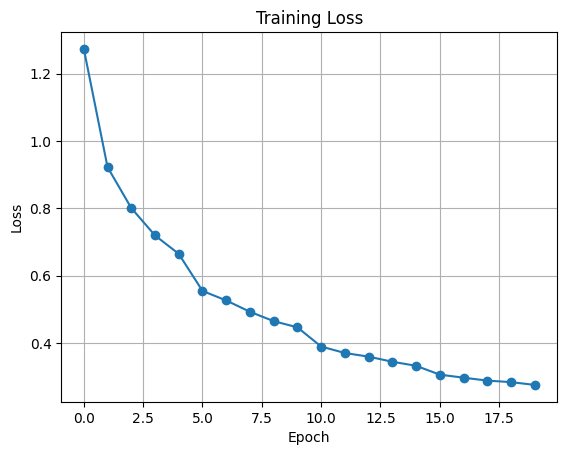

In [7]:
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# **8. Sauvegarde du modèle**

In [8]:
import torch, os
torch.save(model.state_dict(), "/kaggle/working/model.pth")
print("model.pth:", "✅ saved")

model.pth: ✅ saved


# **9. Fonction de prédiction**

In [9]:
from PIL import Image

def predict_image(image):
    """Accepte une PIL Image OU un tensor déjà normalisé."""

    if isinstance(image, torch.Tensor):
        # Tensor déjà normalisé → ajouter batch dimension directement
        img_tensor = image.unsqueeze(0).to(device)
    else:
        # PIL Image → appliquer le transform complet
        transform_test = transforms.Compose([
            transforms.Resize((32, 32)),          # ✓ adapté au CNN 32×32
            transforms.ToTensor(),
            transforms.Normalize(
                (0.5, 0.5, 0.5),                  # ✓ 3 canaux RGB
                (0.5, 0.5, 0.5)
            )
        ])
        img_tensor = transform_test(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs, 1)

    return classes[pred.item()]

# **10. Test sur une image**

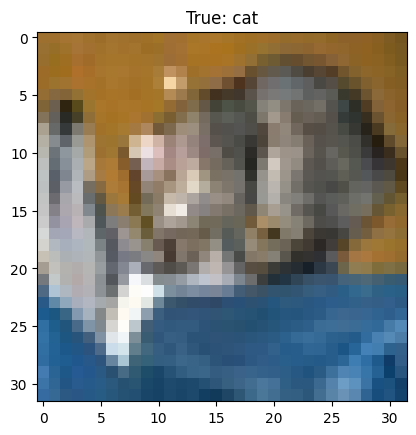

Prediction: cat


In [10]:
img, label = testset[0]

plt.imshow(np.transpose(img.numpy(), (1, 2, 0)) * 0.5 + 0.5)
plt.title(f"True: {classes[label]}")
plt.show()

print("Prediction:", predict_image(img))

# **11. Application Streamlit**

In [11]:
import subprocess
subprocess.run(["pip", "install", "pyngrok", "-q"], check=True)
subprocess.run(["pip", "install", "streamlit", "-q"], check=True)

import os, time
from pyngrok import ngrok, conf

PYTHON = "/usr/local/bin/python"
NGROK_TOKEN = "3BJIfbZohuOTp30RUfTEoruFv1Z_yvtLcWM4JS9CBBgxuUTK"

app_code = (
    "import streamlit as st\n"
    "import torch\n"
    "import torch.nn as nn\n"
    "import torchvision.transforms as transforms\n"
    "import torchvision.models as models\n"
    "from PIL import Image\n"
    "import torch.nn.functional as F\n"
    "import os\n"
    "\n"
    "classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']\n"
    "\n"
    "VALID_IMAGENET = {\n"
    "    'airplane': [404, 405, 895],\n"
    "    'automobile': [407,408,409,410,411,412,436,468,511,627,654,656,705,757,817],\n"
    "    'bird': list(range(7, 24)) + list(range(80, 101)),\n"
    "    'cat': [281, 282, 283, 284, 285],\n"
    "    'deer': [351, 352, 353, 354, 355],\n"
    "    'dog': list(range(151, 269)),\n"
    "    'frog': [30, 31, 32],\n"
    "    'horse': [339, 340],\n"
    "    'ship': [510, 576, 833, 894],\n"
    "    'truck': [555, 569, 656, 675, 717, 734, 757, 864, 867]\n"
    "}\n"
    "ALL_VALID_IDS = set(idx for ids in VALID_IMAGENET.values() for idx in ids)\n"
    "\n"
    "class CNN(nn.Module):\n"
    "    def __init__(self, num_classes=10):\n"
    "        super(CNN, self).__init__()\n"
    "        self.features = nn.Sequential(\n"
    "            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),\n"
    "            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),\n"
    "            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),\n"
    "        )\n"
    "        self.classifier = nn.Sequential(\n"
    "            nn.Dropout(0.4),\n"
    "            nn.Linear(128*4*4, 256),\n"
    "            nn.ReLU(inplace=True),\n"
    "            nn.Linear(256, num_classes)\n"
    "        )\n"
    "    def forward(self, x):\n"
    "        x = self.features(x)\n"
    "        x = x.view(x.size(0), -1)\n"
    "        return self.classifier(x)\n"
    "\n"
    "model = CNN(num_classes=10)\n"
    "model_path = '/kaggle/working/model.pth'\n"
    "if not os.path.exists(model_path):\n"
    "    model_path = '/kaggle/input/datasets/aymanebadia/cifar-model/model.pth'\n"
    "if os.path.exists(model_path):\n"
    "    model.load_state_dict(torch.load(model_path, map_location='cpu'))\n"
    "    model.eval()\n"
    "else:\n"
    "    st.error('Model not found at: ' + model_path)\n"
    "\n"
    "@st.cache_resource\n"
    "def load_mobilenet():\n"
    "    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)\n"
    "    m.eval()\n"
    "    return m\n"
    "\n"
    "mobilenet = load_mobilenet()\n"
    "\n"
    "transform_cifar = transforms.Compose([\n"
    "    transforms.Resize((32, 32)),\n"
    "    transforms.ToTensor(),\n"
    "    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))\n"
    "])\n"
    "\n"
    "transform_mobilenet = transforms.Compose([\n"
    "    transforms.Resize((224, 224)),\n"
    "    transforms.ToTensor(),\n"
    "    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])\n"
    "])\n"
    "\n"
    "def prefilter(image):\n"
    "    img = transform_mobilenet(image).unsqueeze(0)\n"
    "    with torch.no_grad():\n"
    "        out = mobilenet(img)\n"
    "        probs = F.softmax(out, dim=1)\n"
    "        top_ids = torch.argsort(probs[0], descending=True)[:5].tolist()\n"
    "    for idx in top_ids:\n"
    "        if idx in ALL_VALID_IDS:\n"
    "            return True\n"
    "    return False\n"
    "\n"
    "def entropy(probs):\n"
    "    log_p = torch.log(probs + 1e-9)\n"
    "    return float(-torch.sum(probs * log_p).item())\n"
    "\n"
    "MAX_ENTROPY = float(-torch.log(torch.tensor(1.0 / 10)))\n"
    "\n"
    "def is_ood(probs, confidence_threshold=0.80, entropy_threshold=0.60):\n"
    "    confidence, _ = torch.max(probs, 1)\n"
    "    conf_val = confidence.item()\n"
    "    ent_val = entropy(probs)\n"
    "    rel_entropy = ent_val / MAX_ENTROPY\n"
    "    if conf_val < confidence_threshold:\n"
    "        return True, 'low confidence (' + f'{conf_val:.1%})'\n"
    "    if rel_entropy > entropy_threshold:\n"
    "        return True, 'high uncertainty (entropy ' + f'{rel_entropy:.0%} of max)'\n"
    "    return False, 'confidence ' + f'{conf_val:.1%}'\n"
    "\n"
    "st.title('CIFAR-10 Classifier')\n"
    "st.caption('Classes: airplane - automobile - bird - cat - deer - dog - frog - horse - ship - truck')\n"
    "\n"
    "file = st.file_uploader('Choose an image...', type=['jpg','png','jpeg'])\n"
    "\n"
    "if file:\n"
    "    image = Image.open(file).convert('RGB')\n"
    "    st.image(image, caption='Loaded image', use_column_width=True)\n"
    "    if st.button('Run prediction'):\n"
    "        with st.spinner('Analyzing...'):\n"
    "            valid = prefilter(image)\n"
    "            if not valid:\n"
    "                st.warning('UNKNOWN - image does not belong to any CIFAR-10 category')\n"
    "                st.info('Rejected by pre-filter: not airplane, car, bird, cat, deer, dog, frog, horse, ship or truck')\n"
    "            else:\n"
    "                img = transform_cifar(image).unsqueeze(0)\n"
    "                with torch.no_grad():\n"
    "                    output = model(img)\n"
    "                    probs = F.softmax(output, dim=1)\n"
    "                    _, pred = torch.max(probs, 1)\n"
    "                unknown, reason = is_ood(probs)\n"
    "                if unknown:\n"
    "                    st.warning('UNKNOWN - image outside CIFAR-10 classes | Reason: ' + reason)\n"
    "                else:\n"
    "                    predicted_class = classes[pred.item()].upper()\n"
    "                    st.success('Result: ' + predicted_class + ' - ' + reason)\n"
    "                st.divider()\n"
    "                st.subheader('Probability distribution')\n"
    "                prob_dict = {cls: float(p) for cls, p in zip(classes, probs[0])}\n"
    "                st.bar_chart(prob_dict)\n"
)

with open("/kaggle/working/app.py", "w") as f:
    f.write(app_code)

print("Cleaning old processes...")
subprocess.run(["pkill", "-f", "ngrok"], capture_output=True)
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

print("Starting Streamlit in background...")
with open("/kaggle/working/streamlit.log", "w") as sl:
    subprocess.Popen(
        [PYTHON, "-m", "streamlit", "run", "/kaggle/working/app.py",
         "--server.port=8501", "--server.headless=true"],
        stdout=sl, stderr=sl, start_new_session=True
    )
time.sleep(8)

conf.get_default().auth_token = NGROK_TOKEN
try:
    tunnels = ngrok.get_tunnels()
    for t in tunnels:
        ngrok.disconnect(t.public_url)
    print("Connecting to static domain...")
    public_url = ngrok.connect(8501, domain="jolie-intromissive-ken.ngrok-free.dev")
    print("SUCCESS! Your app is live at: " + str(public_url.public_url))
except Exception as e:
    print("Static domain error: " + str(e))
    try:
        ngrok.kill()
        time.sleep(2)
        public_url = ngrok.connect(8501)
        print("SUCCESS (random URL): " + str(public_url.public_url))
    except Exception as e2:
        print("Critical Ngrok failure: " + str(e2))

Cleaning old processes...
Starting Streamlit in background...


t=2026-03-24T20:00:48+0000 lvl=warn msg="failed to start tunnel" pg=/api/tunnels id=9a889b283d9b384c err="failed to start tunnel: The endpoint 'https://jolie-intromissive-ken.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"


Connecting to static domain...
Static domain error: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://jolie-intromissive-ken.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}



t=2026-03-24T20:00:50+0000 lvl=warn msg="failed to start tunnel" pg=/api/tunnels id=bd8353034deaded9 err="failed to start tunnel: The endpoint 'https://jolie-intromissive-ken.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"


Critical Ngrok failure: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://jolie-intromissive-ken.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}

